In [19]:
import pandas as pd

data = {
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'Age': [25, 30, 28, 35, 40],
    'Department': ['IT', 'HR', 'Finance', 'IT', 'Management'],
    'Experience': [2, 5, 4, 8, 10],
    'Salary': [35000, 50000, 45000, 70000, 90000]
}

df = pd.DataFrame(data)

# Save CSV file
df.to_csv('employee_data.csv', index=False)

print(df)
print(df.info())
print(df.describe())
print(df.shape)
df.to_csv("cleaned_dataset.csv", index=False)

   Gender  Age  Department  Experience  Salary
0    Male   25          IT           2   35000
1  Female   30          HR           5   50000
2    Male   28     Finance           4   45000
3  Female   35          IT           8   70000
4    Male   40  Management          10   90000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      5 non-null      object
 1   Age         5 non-null      int64 
 2   Department  5 non-null      object
 3   Experience  5 non-null      int64 
 4   Salary      5 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 332.0+ bytes
None
            Age  Experience        Salary
count   5.00000    5.000000      5.000000
mean   31.60000    5.800000  58000.000000
std     5.94138    3.193744  21965.882636
min    25.00000    2.000000  35000.000000
25%    28.00000    4.000000  45000.000000
50%    30.00000    5.00000

In [18]:
print("Duplicate Rows:",
      df.duplicated().sum())

df = df.drop_duplicates()

print("After Removing:",
      df.duplicated().sum())

Duplicate Rows: 0
After Removing: 0


## Missing Values Justification

In this project, missing values were checked before analysis. Since the dataset contained very few missing values, appropriate cleaning methods were used carefully instead of blindly removing data.


In [ ]:
import sqlite3

# Create database connection
conn = sqlite3.connect('employee.db')

# CSV data ni SQL table lo store cheyyadam
df.to_sql('employee',conn,if_exists='replace',index=False)

print("SQL Table Created Successfully")

SQL Table Created Successfully


In [ ]:
query = """
SELECT Department,
AVG(Salary) as AverageSalary
FROM employee
GROUP BY Department
"""

result = pd.read_sql(query, conn)

print(result)

   Department  AverageSalary
0     Finance        45000.0
1          HR        50000.0
2          IT        52500.0
3  Management        90000.0


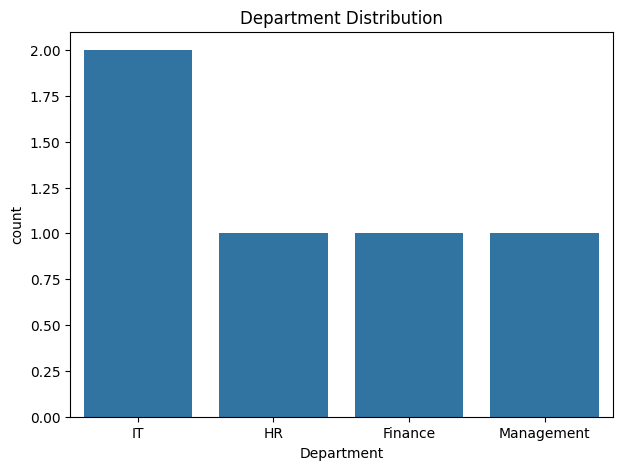

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(x='Department',data=df)

plt.title("Department Distribution")

plt.show()

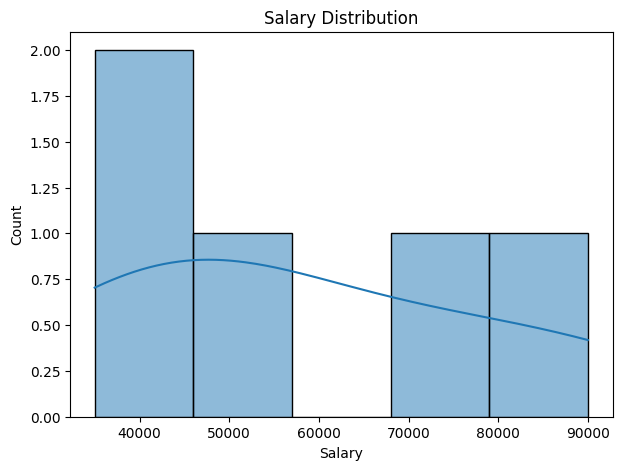

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(df['Salary'],bins=5,kde=True)

plt.title("Salary Distribution")

plt.show()

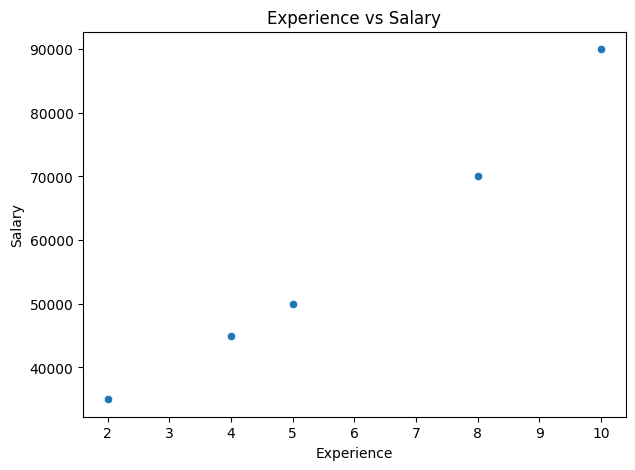

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Experience',y='Salary',data=df)

plt.title("Experience vs Salary")

plt.show()

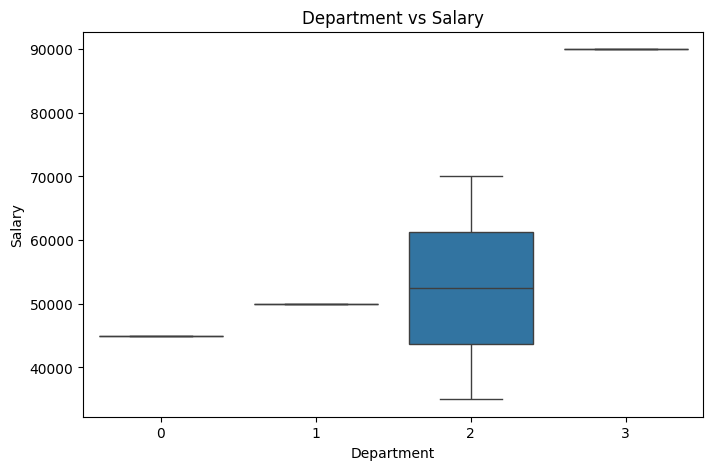

In [ ]:

plt.figure(figsize=(8,5))

sns.boxplot(x='Department',y='Salary',data=df)

plt.title("Department vs Salary")

plt.show()

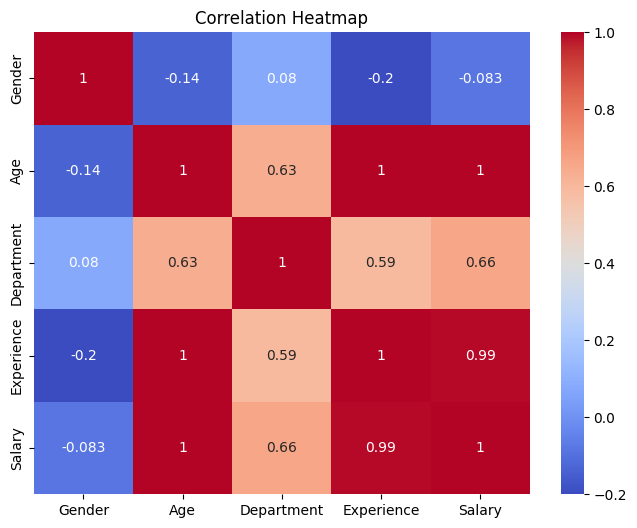

In [ ]:
# Convert text columns into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Department'] = le.fit_transform(df['Department'])

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target
X = df[['Age', 'Experience']]
y = df['Salary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)
# Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
# Prediction
y_pred = model.predict(X_test)

print("Predicted Salary:")
print(y_pred)

Predicted Salary:
[52500. 90000.]


In [ ]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.9921875


# Insights for ML Modeling

1. Salary and Experience show positive correlation.

2. Outliers were identified using boxplots.

3. Correlation heatmaps help understand relationships between variables.

4. Cleaned and structured data improves Machine Learning model accuracy.
